# **NOTEBOOK 3: Linear Regression Model**

In [37]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, median_absolute_error
import seaborn as sns
from matplotlib import pyplot as plt

## Load Dataset

In [8]:
def load_dataset():
    file_path = Path.home() / 'Documents/IDX Internship/Raw Data'
    
    # all 30 datasets
    files = [
        file_path / 'CRMLSSold20220101_20231231_filled.csv', file_path / 'CRMLSSold202401_filled.csv',
        file_path / 'CRMLSSold202402_filled.csv', file_path / 'CRMLSSold202403_filled.csv',
        file_path / 'CRMLSSold202404_filled.csv', file_path / 'CRMLSSold202405_filled.csv',
        file_path / 'CRMLSSold202406_filled.csv', file_path / 'CRMLSSold202407_filled.csv',
        file_path / 'CRMLSSold202408.csv', file_path / 'CRMLSSold202409.csv',
        file_path / 'CRMLSSold202410.csv', file_path / 'CRMLSSold202411.csv',
        file_path / 'CRMLSSold202412.csv', file_path / 'CRMLSSold202501_filled.csv',
        file_path / 'CRMLSSold202502.csv', file_path / 'CRMLSSold202503.csv',
        file_path / 'CRMLSSold202504.csv', file_path / 'CRMLSSold202505.csv',
        file_path / 'CRMLSSold202506.csv', file_path / 'CRMLSSold202507.csv',
        file_path / 'CRMLSSold202508.csv', file_path / 'CRMLSSold202509.csv',
        file_path / 'CRMLSSold202510.csv', file_path / 'CRMLSSold202511.csv',
        file_path / 'CRMLSSold202512.csv', file_path / 'CRMLSSold202601.csv',
        file_path / 'CRMLSSold202602.csv', file_path / 'CRMLSSold202603.csv',
        file_path / 'CRMLSSold202604.csv', file_path / 'CRMLSSold202605.csv',
    ]
    
    # dtype to str to handle mixed value types for some columns
    data_dfs = [pd.read_csv(f, dtype={'WaterfrontYN': str, 'PostalCode': str, 'latfilled': str, 'lonfilled': str,
                                      'ElementarySchool': str, 'BuilderName': str, 'CoBuyerAgentFirstName': str,
                                      'PoolPrivateYN': str}) for f in files]
    df = pd.concat(data_dfs, ignore_index=True)

    return df

df = load_dataset()
print(df.shape)

(794271, 82)


## Data Preprocessing

In [9]:
def preprocessing():

    # load dataset
    df = load_dataset()
    
    # restrict analysis to residential and single family
    df = df[
        (df['PropertyType'] == 'Residential') &
        (df['PropertySubType'] == 'SingleFamilyResidence')].copy()

    # convert CloseDate to datetime dtype
    df['CloseDate'] = pd.to_datetime(df['CloseDate'])


    preprocessed_df = df.copy()
    
    
    # drop columns not known at prediction time
    drop_cols = ['ListPrice', 'DaysOnMarket', 'OriginalListPrice']
    preprocessed_df = preprocessed_df.drop(columns=drop_cols)

    # count missing values
    missing = pd.DataFrame({
        'Total Missing Values': preprocessed_df.isnull().sum(),
        'Proportion Missing': preprocessed_df.isnull().mean()
    })

    # drop column if null rate above 50%
    threshold = 0.5
    null_50 = missing[missing['Proportion Missing'] > threshold].index.tolist()
    preprocessed_df = preprocessed_df.drop(columns=null_50)

    # drop columns with no plausible relationship to ClosePrice
    unrelated = ['ContractStatusChangeDate', 'MlsStatus', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'ListingId',
                 'PurchaseContractDate', 'ListingContractDate', 'ListAgentEmail', 'ListOfficeName', 'BuyerOfficeName',
                 'ListingKey', 'ListingKeyNumeric', 'ListAgentFirstName', 'ListAgentLastName', 'StreetNumberNumeric',
                 'ListAgentFullName', 'BuyerAgentMlsId', 'BuyerOfficeAOR', 'BuyerAgentAOR', 'ListAgentAOR',
                 'UnparsedAddress']
    preprocessed_df = preprocessed_df.drop(columns=unrelated)

    # fill values with less than 50% null rate
    # sentinel fill
    preprocessed_df['ParkingTotal'] = preprocessed_df['ParkingTotal'].fillna(0)
    preprocessed_df['GarageSpaces'] = preprocessed_df['GarageSpaces'].fillna(0)
    preprocessed_df['MainLevelBedrooms'] = preprocessed_df['MainLevelBedrooms'].fillna(0)
    
    # median fill
    for col in ['LotSizeSquareFeet', 'YearBuilt', 'Stories', 'Latitude', 'Longitude', 'BedroomsTotal',
                'BathroomsTotalInteger']:
        preprocessed_df[col] = preprocessed_df[col].fillna(preprocessed_df[col].median())

    # create binary has_hoa feature from AssociationFee
    preprocessed_df['AssociationFee'] = preprocessed_df['AssociationFee'].fillna(0)
    preprocessed_df["has_hoa"] = (preprocessed_df["AssociationFee"] > 0).astype(int)
    
    # drop features with zero variance
    preprocessed_df = preprocessed_df.drop(columns=['PropertyType', 'PropertySubType'])

    # keep only one area column (LotSizeSquareFeet)
    preprocessed_df = preprocessed_df.drop(columns=['LotSizeArea', 'LotSizeAcres'])

    # fill null values for certain bool values with False
    for col in ['ViewYN', 'PoolPrivateYN', 'AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN']:
        preprocessed_df[col] = preprocessed_df[col].astype(bool)
        preprocessed_df[col] = preprocessed_df[col].fillna(False).astype(int)

    # fill missing values for certain categorical variables with 'Unknown'
    for col in ['Flooring', 'HighSchoolDistrict', 'MLSAreaMajor', 'Levels', 'City']:
        preprocessed_df[col] = preprocessed_df[col].fillna('Unknown')

    # replace StateOrProvince (almost no variance) with binary InCalifornia variable
    preprocessed_df["InCalifornia"] = (preprocessed_df["StateOrProvince"] == "CA").astype(int)
    preprocessed_df = preprocessed_df.drop(columns=['StateOrProvince'])
    
    # fill missing value for CountyOrParish with mode
    preprocessed_df['CountyOrParish'] = preprocessed_df['CountyOrParish'].fillna(
        preprocessed_df['CountyOrParish'].mode()[0]
    )

    # drop rows with missing values for target variable and other important features with very little null values
    preprocessed_df = preprocessed_df.dropna(subset=['ClosePrice', 'LivingArea', 'PostalCode'])

    # multi-label encode Flooring feature
    preprocessed_df['Flooring_SeeRemarks'] = (preprocessed_df['Flooring'].str.contains('SeeRemarks').astype(int))
    preprocessed_df['Flooring'] = (preprocessed_df['Flooring'].str.replace('SeeRemarks,?', '', regex=True))
    flooring_dummies = (preprocessed_df['Flooring'].str.get_dummies(sep=','))
    
    preprocessed_df = pd.concat(
        [preprocessed_df.drop(columns=['Flooring']), flooring_dummies.add_prefix('Flooring_')], axis=1)

    # frequency encode MLSAreaMajor
    area_frequency = preprocessed_df['MLSAreaMajor'].value_counts()
    preprocessed_df['MLSAreaMajor_freq'] = (preprocessed_df['MLSAreaMajor'].map(area_frequency))
    
    preprocessed_df = preprocessed_df.drop(columns=['MLSAreaMajor'])

    # one-hot encode CountyOrParish
    preprocessed_df['CountyOrParish'] = (preprocessed_df['CountyOrParish'].str.title()) # standard capitalization
    preprocessed_df['CountyOrParish'] = (preprocessed_df['CountyOrParish'].replace(
        ['Foreign Country', 'Other County', 'Other State', 'Other'], 'Other')) # replace non-counties with 'Other'
    preprocessed_df = pd.get_dummies(preprocessed_df,columns=['CountyOrParish'],drop_first=True)

    # multi-label encode Levels
    # create multi-label dummy variables
    levels_dummies = (preprocessed_df['Levels'].str.get_dummies(sep=','))
    levels_dummies = levels_dummies.add_prefix('Levels_') # add prefix
    
    preprocessed_df = pd.concat([preprocessed_df.drop(columns=['Levels']),levels_dummies],axis=1)

    # group cities with less than 500 entires and one-hot encode City
    city_counts = preprocessed_df['City'].value_counts()
    rare_cities = city_counts[city_counts < 500].index
    preprocessed_df['City'] = (preprocessed_df['City'].replace(rare_cities, 'Other'))
    preprocessed_df = pd.get_dummies(preprocessed_df, columns=['City'], drop_first=True)

    # group districts with less than 100 entries and one-hot encode HighSchoolDistrict
    district_counts = preprocessed_df['HighSchoolDistrict'].value_counts()
    rare_districts = district_counts[district_counts < 100].index
    preprocessed_df['HighSchoolDistrict'] = (preprocessed_df['HighSchoolDistrict'].replace(rare_districts, 'Other'))
    preprocessed_df = pd.get_dummies(preprocessed_df, columns=['HighSchoolDistrict'], drop_first=True)

    # frequency encode PostalCode
    postal_counts = preprocessed_df['PostalCode'].value_counts()
    preprocessed_df['PostalCode_freq'] = (preprocessed_df['PostalCode'].map(postal_counts))
    preprocessed_df = preprocessed_df.drop(columns=['PostalCode'])

    return preprocessed_df

preprocessed_df = preprocessing()
preprocessed_df.shape

(398943, 563)

## Train-Test Split
Parameters:
* df: dataframe containing CloseDate
* train_months: number of months before test month to use for training

Returns:
* X_train, X_test, y_train, y_test

In [10]:
def train_test_split(df, train_months):

    df = df.copy()

    # ensure datetime
    df['CloseDate'] = pd.to_datetime(df['CloseDate'])

    # get monthly periods
    df['CloseMonth'] = df['CloseDate'].dt.to_period('M')

    # most recent month becomes test
    latest_month = df['CloseMonth'].max()

    test_df = df[df['CloseMonth'] == latest_month]

    # X months immediately before test month
    train_start = latest_month - train_months

    train_df = df[(df['CloseMonth'] < latest_month) & (df['CloseMonth'] >= train_start)]

    # remove date columns
    train_df = train_df.drop(columns=['CloseDate', 'CloseMonth'])

    test_df = test_df.drop(columns=['CloseDate', 'CloseMonth'])

    # separate target
    X_train = train_df.drop(columns=['ClosePrice'])
    y_train = train_df['ClosePrice']

    X_test = test_df.drop(columns=['ClosePrice'])
    y_test = test_df['ClosePrice']

    return X_train, X_test, y_train, y_test

In [11]:
df = preprocessing()

X = 12
X_train, X_test, y_train, y_test = train_test_split(df, X)

## Linear Regression Model

In [25]:
# define MdAPE
def mdape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    ape = np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]) * 100
    return np.median(ape)

# define metrics function
def metrics(y_true, y_pred):
      return {
          'R2': r2_score(y_true, y_pred),
          'MAE': mean_absolute_error(y_true, y_pred),
          'RMSE': root_mean_squared_error(y_true, y_pred),
          'MedianAbsoluteError': median_absolute_error(y_true, y_pred),
          'MDAPE': mdape(y_true, y_pred)
      }

In [26]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print('Linear Regression:', metrics(y_test, lr.predict(X_test)))

Linear Regression: {'R2': 0.3022847910296327, 'MAE': 529642.2960223729, 'RMSE': 1401042.35255363, 'MedianAbsoluteError': 308700.12225838006, 'MDAPE': np.float64(30.231571051851923)}


In [35]:
# evaluate linear regression model on different train dataset sizes

df = preprocessing()

results = []

train_months = [6, 12, 15, 18, 20, 25, 30, 35, 40]

for months in train_months:

    X_train, X_test, y_train, y_test = train_test_split(df, months)

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    res = metrics(y_test, y_pred)
    res['TrainMonths'] = months

    results.append(res)

results = pd.DataFrame(results)
results

,R2,MAE,RMSE,MedianAbsoluteError,MDAPE,TrainMonths
0,0.228111,522023.862811,1.473634e+06,294412.723793,29.141452,6
1,0.302285,529642.296022,1.401042e+06,308700.122258,30.231571,12
2,0.339047,496886.147278,1.363633e+06,291813.067219,28.544476,15
3,0.371561,472803.768278,1.329669e+06,278298.010782,27.635442,18
4,0.386163,461754.851517,1.314131e+06,276466.917409,27.410267,20
5,0.413006,428108.518350,1.285077e+06,254794.673218,25.702441,25
6,0.423736,416155.717148,1.273277e+06,249575.016173,25.245765,30
7,0.429050,408581.198730,1.267393e+06,248980.800173,25.113157,35
8,0.429358,409270.126180,1.267050e+06,249625.066547,25.221720,40


In [36]:
# number of unique months
df['CloseDate'].dt.to_period('M').unique().size

53

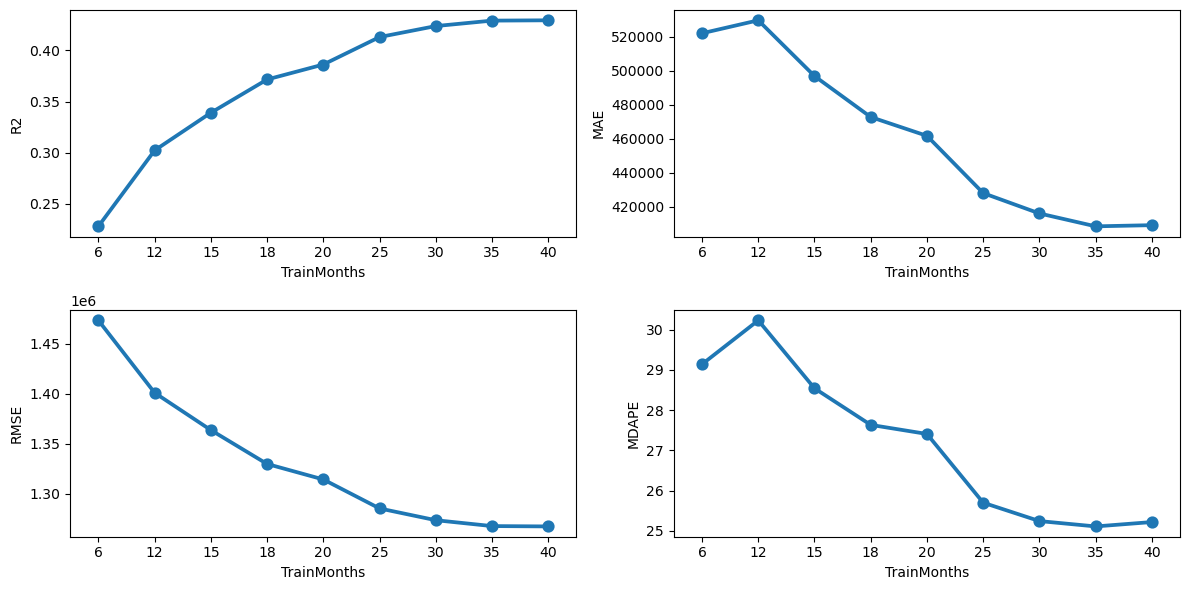

In [41]:
fig, ax = plt.subplots(2, 2, figsize=(12, 6))
sns.pointplot(data=results, x='TrainMonths', y='R2', ax=ax[0,0])
sns.pointplot(data=results, x='TrainMonths', y='MAE', ax=ax[0,1])
sns.pointplot(data=results, x='TrainMonths', y='RMSE', ax=ax[1,0])
sns.pointplot(data=results, x='TrainMonths', y='MDAPE', ax=ax[1,1])
plt.tight_layout()